In [25]:
!git clone https://github.com/jasonfghx/GNN.git

fatal: destination path 'GNN' already exists and is not an empty directory.


In [ ]:
!pip install rdkit torch torch-geometric
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy

以上跑完後整個重新啟動

In [8]:
import pandas as pd
from rdkit import Chem
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.QED import qed
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency')

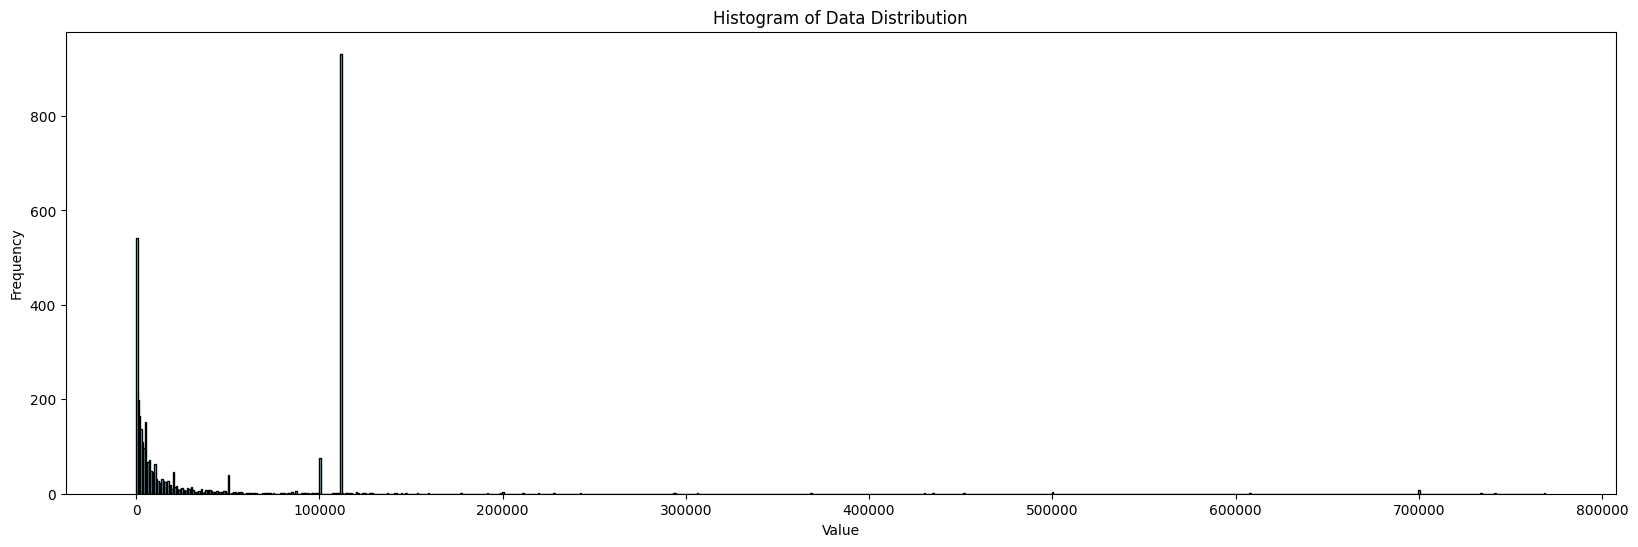

In [26]:
data=pd.read_csv("/content/GNN/資料集.csv")
data=data.iloc[1:,:]
data=data[~data['Unnamed: 2'].isnull()]
data=data[~data['Unnamed: 1'].isnull()]
data=data.iloc[:-1,:]
data['Unnamed: 2']=data['Unnamed: 2'].astype("float")

data=data[data['Unnamed: 2']<1000000]
bin=1000
plt.figure(figsize=(20, 6))
plt.hist(data['Unnamed: 2'], bins=bin, color='skyblue', edgecolor='black')

# 添加標題和標籤
plt.title('Histogram of Data Distribution')
plt.xlabel('Value')
# 100000 是差異
plt.ylabel('Frequency')


In [27]:
desc_names = [
    'MolWt', 'HeavyAtomCount', 'NumAtoms', 'NumRings', 'NumAromaticRings', 'FractionCSP3',
    'MolLogP', 'TPSA', 'LabuteASA',
    'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds',
    'BalabanJ', 'BertzCT', 'HallKierAlpha', 'Chi0v', 'Chi1v',
    'PEOE_VSA1', 'PEOE_VSA9', 'EState_VSA3'
]
def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [None]*len(desc_names)
    values = []
    for desc_name in desc_names:
        if desc_name == 'NumAtoms':
            # 用 Mol 物件的 GetNumAtoms 方法來計算
          values.append(mol.GetNumAtoms())
        elif desc_name == 'NumRings':
            # 使用 mol.GetRingInfo().NumRings() 來計算環數
          values.append(len(mol.GetRingInfo().AtomRings()))
        else:
          func = getattr(Descriptors, desc_name)
          values.append(func(mol))
    return values

desc_values = data['Unnamed: 1'].apply(calc_descriptors)
desc_df = pd.DataFrame(desc_values.tolist(), columns=desc_names)

In [28]:
desc_df=desc_df.reset_index(drop=True,inplace=False)
data=data.reset_index(drop=True,inplace=False)
desc_df['Standard']=data['Unnamed: 2']
desc_df['Standard1']=desc_df['Standard'].apply(lambda x:'blue' if x>=10000 else 'red')
desc_df1 = desc_df.drop(columns=['Standard'])

# 3553

In [32]:
import numpy as np

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(desc_df.iloc[:,:-2])

/tmp/ipython-input-3792378359.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=desc_df['Standard1'], cmap='viridis')


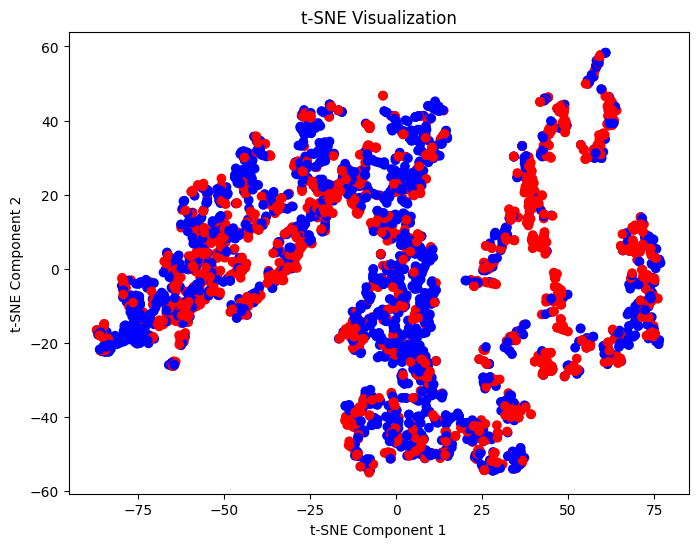

Standard1
blue    1818
red     1735
Name: count, dtype: int64


In [33]:
# 繪製 t-SNE 圖
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=desc_df['Standard1'], cmap='viridis')
plt.title('t-SNE Visualization')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.show()
print(desc_df['Standard1'].value_counts())

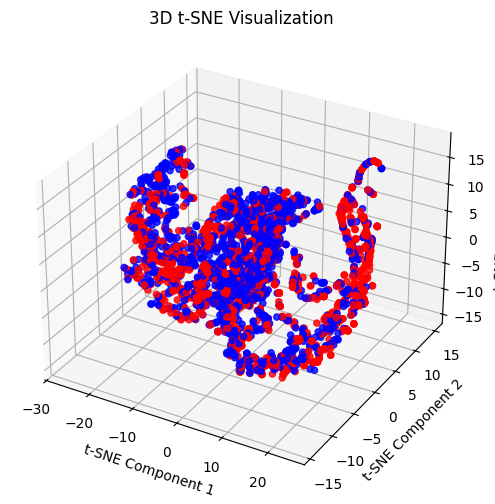

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 匯入3D工具

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # 建立3D座標軸
pd.DataFrame(X_tsne).to_csv("TSNE_3.csv")
# 畫出3D散點圖
sc = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2],
    c=desc_df['Standard1'],
    # cmap='viridis',
    alpha=0.8
)

# 設定標題與軸標籤
ax.set_title('3D t-SNE Visualization')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')

plt.show()


In [19]:
!pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/tmp/ipython-input-3858539143.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_umap[:, 0], X_umap[:, 1], c=desc_df['Standard1'], cmap='viridis')


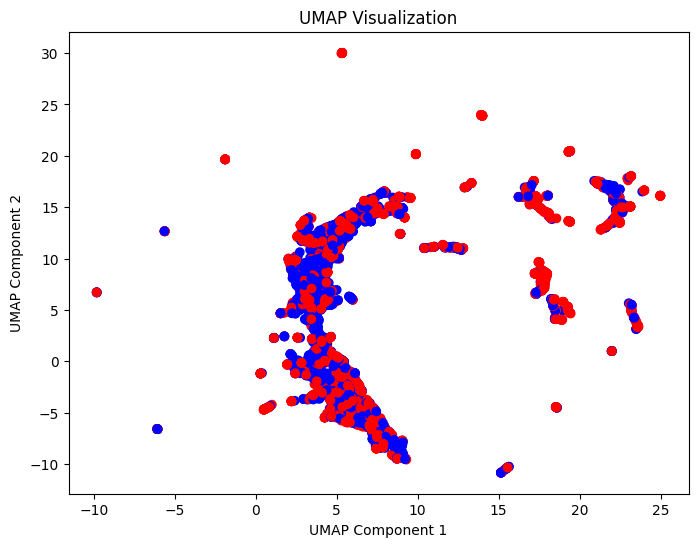

In [20]:
import umap
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(desc_df.iloc[:,:-2])

# 繪製 UMAP 圖
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=desc_df['Standard1'], cmap='viridis')
plt.title('UMAP Visualization')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


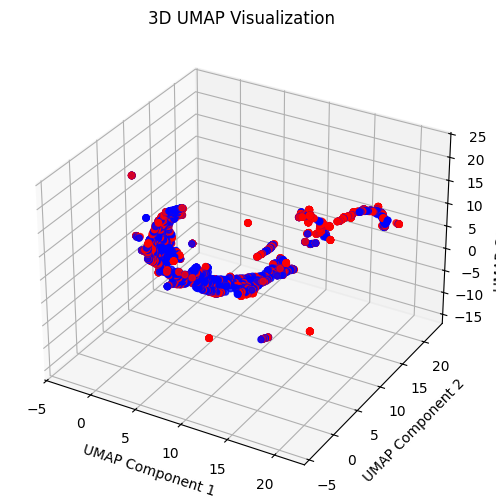

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 匯入3D工具
umap_model = umap.UMAP(n_components=3, random_state=42)
X_umap = umap_model.fit_transform(desc_df.iloc[:,:-2])
pd.DataFrame(X_umap).to_csv("UMAP_3.csv")
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # 建立3D座標軸

# 畫出3D散點圖
sc = ax.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    X_umap[:, 2],
    c=desc_df['Standard1'],
    # cmap='viridis',
    alpha=0.8
)

# 設定標題與軸標籤
ax.set_title('3D UMAP Visualization')
ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_zlabel('UMAP Component 3')

plt.show()


/tmp/ipython-input-1122680099.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_PCA[:, 0], X_PCA[:, 1], c=desc_df['Standard1'], cmap='viridis')


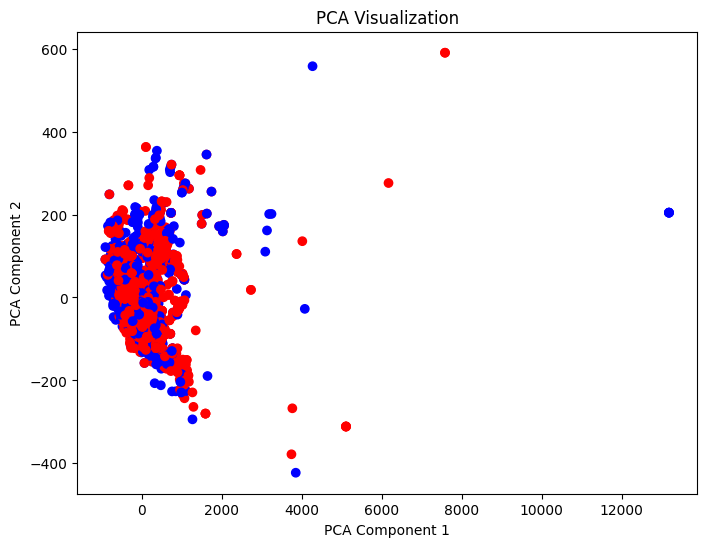

In [15]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_PCA = pca.fit_transform(desc_df.iloc[:,:-2])

# 繪製 UMAP 圖
plt.figure(figsize=(8, 6))
plt.scatter(X_PCA[:, 0], X_PCA[:, 1], c=desc_df['Standard1'], cmap='viridis')
plt.title('PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

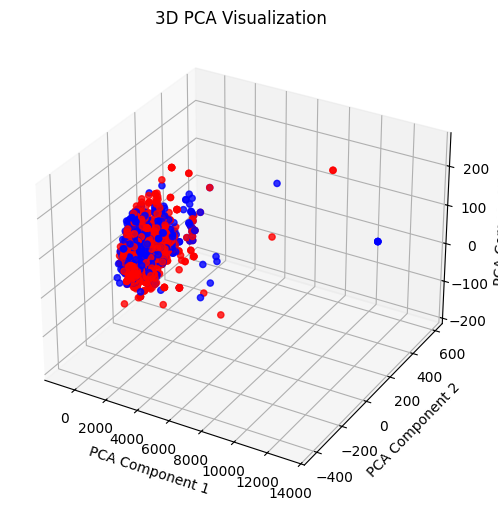

In [24]:
pca = PCA(n_components=3)
X_PCA = pca.fit_transform(desc_df.iloc[:,:-2])
pd.DataFrame(X_PCA).to_csv("PCA_3.csv")
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')  # 建立3D座標軸

# 畫出3D散點圖
sc = ax.scatter(
    X_PCA[:, 0],
    X_PCA[:, 1],
    X_PCA[:, 2],
    c=desc_df['Standard1'],
    # cmap='viridis',
    alpha=0.8
)

# 設定標題與軸標籤
ax.set_title('3D PCA Visualization')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

plt.show()
